## Big Data Analytics of E-Commerce Purchase History for Customer Behavior and Sales Trend Analysis

**DATASET**

**Description**: eCommerce Purchase History from Electronics Store(kaggle) This dataset contains purchase data from April 2020 to November 2020 from a large home appliances and electronics online store.Each row in the file represents an event. All events are related to products and users. Each event is like many-to-many relation between products and users. Data collected by Open CDP project. Feel free to use open source customer data platform.<br>

**Dataset Link**:https://www.kaggle.com/datasets/mkechinov/ecommerce-purchase-history-from-electronics-store

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Import Dataset

In [11]:
df = pd.read_csv('./data/kz.csv')
print(df.shape)

(2633521, 8)


## EDA

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2633521 entries, 0 to 2633520
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   order_id       int64  
 2   product_id     int64  
 3   category_id    float64
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        float64
dtypes: float64(3), int64(2), str(3)
memory usage: 270.4 MB
None


In [14]:
df.isnull().sum()

event_time             0
order_id               0
product_id             0
category_id       431954
category_code     612202
brand             506005
price             431954
user_id          2069352
dtype: int64

In [15]:
df.describe(include='all')

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
count,2633521,2.633521e+06,2.633521e+06,2.201567e+06,2021319,2127516,2.201567e+06,5.641690e+05
unique,1316174,NaN,NaN,NaN,510,23021,NaN,NaN
top,1970-01-01 00:33:40 UTC,NaN,NaN,NaN,electronics.smartphone,samsung,NaN,NaN
freq,19631,NaN,NaN,NaN,357682,358928,NaN,NaN
mean,NaN,2.361783e+18,1.674080e+18,2.273827e+18,NaN,NaN,1.540932e+02,1.515916e+18
std,NaN,1.716538e+16,3.102249e+17,2.353247e+16,NaN,NaN,2.419421e+02,2.377083e+07
min,NaN,2.294360e+18,1.515966e+18,2.268105e+18,NaN,NaN,0.000000e+00,1.515916e+18
25%,NaN,2.348807e+18,1.515966e+18,2.268105e+18,NaN,NaN,1.456000e+01,1.515916e+18
50%,NaN,2.353254e+18,1.515966e+18,2.268105e+18,NaN,NaN,5.553000e+01,1.515916e+18
75%,NaN,2.383131e+18,1.515966e+18,2.268105e+18,NaN,NaN,1.967400e+02,1.515916e+18


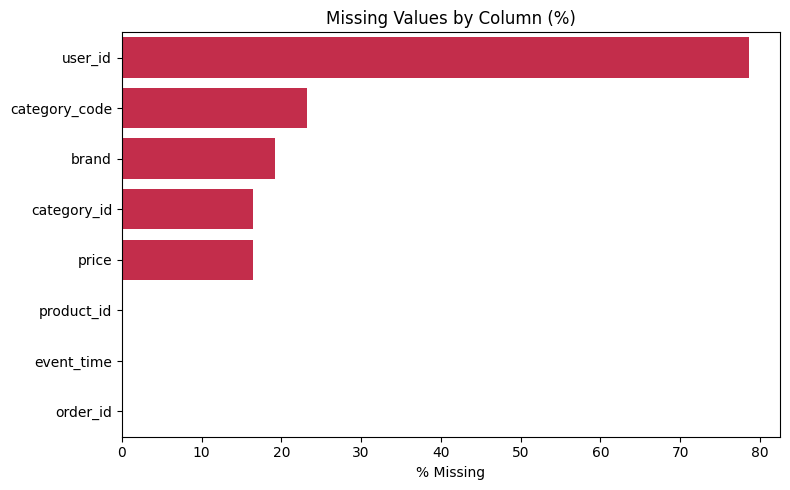

In [22]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

plt.figure(figsize=(8,5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="crimson")
plt.title("Missing Values by Column (%)")
plt.xlabel("% Missing")
plt.ylabel('')
plt.tight_layout()
plt.show()

In [23]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Total rows:", len(df))

Exact duplicate rows: 675
Total rows: 2633521


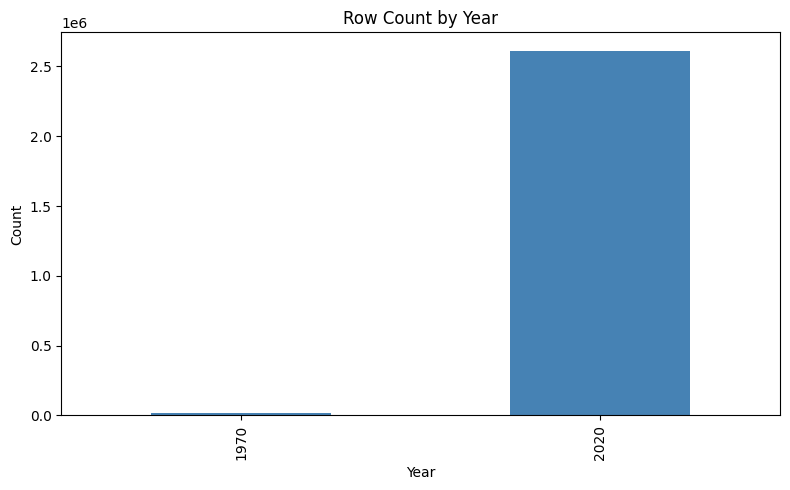

In [25]:
df["event_time_parsed"] = pd.to_datetime(df["event_time"], errors="coerce")
df["year"] = df["event_time_parsed"].dt.year

plt.figure(figsize=(8,5))
df["year"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Row Count by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

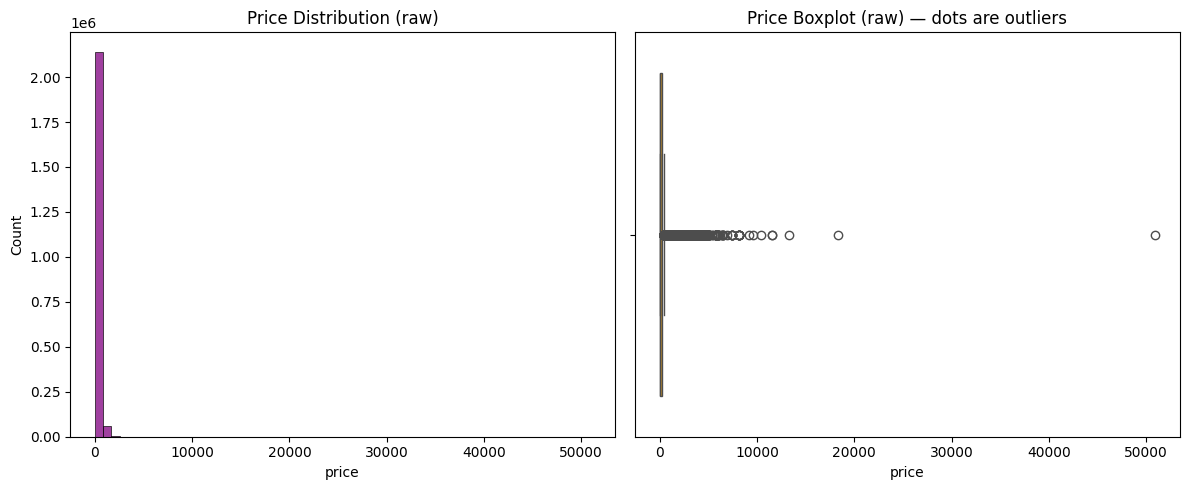

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df["price"].dropna(), bins=60, ax=axes[0], color="purple")
axes[0].set_title("Price Distribution (raw)")

sns.boxplot(x=df["price"].dropna(), ax=axes[1], color="orange")
axes[1].set_title("Price Boxplot (raw) — dots are outliers")
plt.tight_layout()
plt.show()

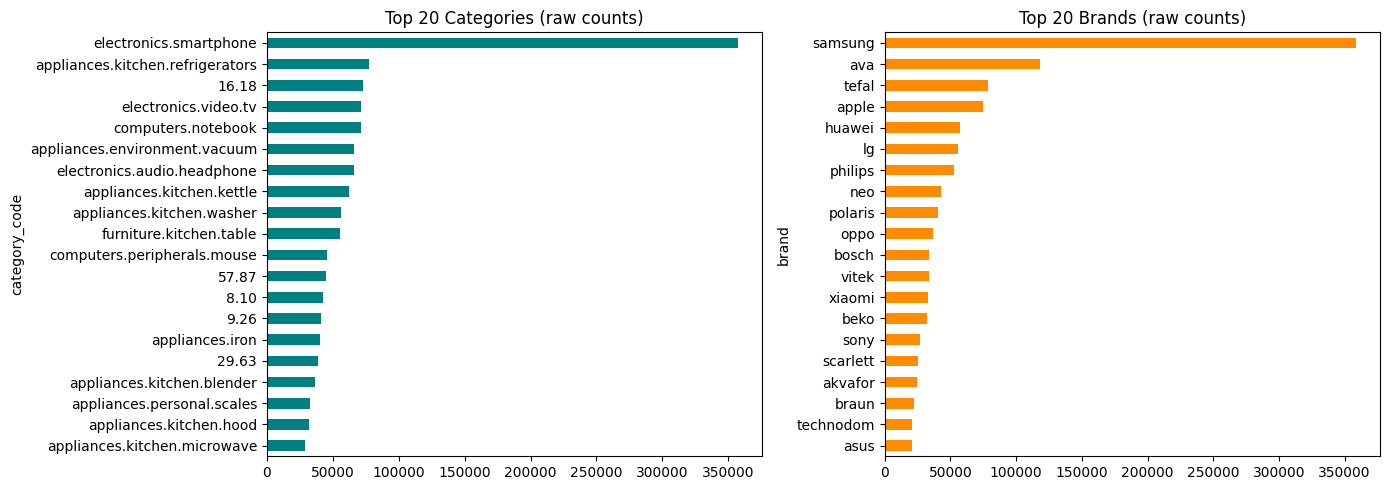

Total categories: 510, total brands: 23021


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df["category_code"].value_counts().head(20).plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Top 20 Categories (raw counts)")
axes[0].invert_yaxis()

df["brand"].value_counts().head(20).plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Top 20 Brands (raw counts)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total categories: {df['category_code'].nunique()}, total brands: {df['brand'].nunique()}")

## Pre-processing & Cleaning the data